In [1]:
import json
import os
import shutil
import tempfile

import numpy as np
from affine import Affine
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from rasterio.windows import Window
from rasterio.windows import bounds as window_bounds

from reV import TESTDATADIR
from reV.bespoke.pack_turbs import get_xy
from reV.bespoke.bespoke import BespokeSinglePlant
from reV.supply_curve.tech_mapping import TechMapping

In [2]:
SAM = os.path.join(TESTDATADIR, 'SAM/i_windpower.json')
EXCL = os.path.join(TESTDATADIR, 'ri_exclusions/ri_exclusions.h5')
RES = os.path.join(TESTDATADIR, 'wtk/ri_100_wtk_{}.h5')
SPL = os.path.join(TESTDATADIR, 'bespoke/ri_sc33_spl.h5')
OBS = os.path.join(TESTDATADIR, 'bespoke/ri_sc33_observers.tif')
TM_DSET = 'techmap_wtk_ri_100'

# note that this differs from the
EXCL_DICT = {'ri_srtm_slope': {'include_range': (None, 5),
                               'exclude_nodata': False},
             'ri_padus': {'exclude_values': [1],
                          'exclude_nodata': False},
             'ri_reeds_regions': {'include_range': (None, 400),
                                  'exclude_nodata': False}}

with open(SAM) as f:
    SAM_SYS_INPUTS = json.load(f)

SAM_SYS_INPUTS['wind_farm_wake_model'] = 2
SAM_SYS_INPUTS['wind_farm_losses_percent'] = 0
del SAM_SYS_INPUTS['wind_resource_filename']
TURB_RATING = np.max(SAM_SYS_INPUTS['wind_turbine_powercurve_powerout'])
SAM_CONFIGS = {'default': SAM_SYS_INPUTS}

In [3]:
def plot_poly(geom, resolution, pixel_size, ax=None, color="black",
              linestyle="--", linewidth=0.5):
    """plot the wind plant boundaries

    Parameters
    ----------
    geom : Polygon | MultiPolygon
        The shapely.Polygon or shapely.MultiPolygon that define the wind
        plant boundary(ies).
    resolution : int
        The number of cells in a supply curve point.
    pixel_size : int
        The number of meters in a single pixel side.
    ax : :py:class:`matplotlib.pyplot.axes`, optional
        The figure axes on which the wind rose is plotted.
        Defaults to :obj:`None`.
    color : string, optional
        The color for the wind plant boundaries
    linestyle : string, optional
        Style to plot the boundary lines
    linewidth : float, optional
        The width of the boundary lines
    """
    if ax is None:
        _, ax = plt.subplots()

    sc_left = 0
    sc_bottom = 0
    sc_right = resolution * pixel_size
    sc_top = resolution * pixel_size

    if geom.geom_type == 'Polygon':
        exterior_coords = geom.exterior.coords[:]
        x, y = get_xy(exterior_coords)
        ax.fill(x, y, color="C0", alpha=0.25)
        ax.plot(x, y, color=color, linestyle=linestyle, linewidth=linewidth)

        for interior in geom.interiors:
            interior_coords = interior.coords[:]
            x, y = get_xy(interior_coords)
            ax.fill(x, y, color="white", alpha=1.0)
            ax.plot(x, y, "--k", linewidth=0.5)

    elif geom.geom_type == 'MultiPolygon':

        for part in geom.geoms:
            exterior_coords = part.exterior.coords[:]
            x, y = get_xy(exterior_coords)
            ax.fill(x, y, color="C0", alpha=0.25)
            ax.plot(x, y, color=color, linestyle=linestyle,
                    linewidth=linewidth)

            for interior in part.interiors:
                interior_coords = interior.coords[:]
                x, y = get_xy(interior_coords)
                ax.fill(x, y, color="white", alpha=1.0)
                ax.plot(x, y, "--k", linewidth=0.5)

    sc_boundary = Rectangle(
        (sc_left, sc_bottom),
        sc_right - sc_left,
        sc_top - sc_bottom,
        fill=False,
        edgecolor="C0",
        linewidth=1.5,
        label="SC boundary",
    )
    ax.add_patch(sc_boundary)

    packing_polygons_handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="C0",
        alpha=0.25,
        edgecolor=color,
        linestyle="--",
        linewidth=0.5,
        label="Packing polygons",
    )

    return ax, packing_polygons_handle


def plot_turbines(x, y, r, ax=None, color="C0", nums=False):
    """plot wind turbine locations

    Parameters
    ----------
    x, y : array
        Wind turbine x and y locations
    r : float
        Wind turbine radius
    ax :py:class:`matplotlib.pyplot.axes`, optional
        The figure axes on which the wind rose is plotted.
        Defaults to :obj:`None`.
    color : string, optional
        The color for the wind plant boundaries
    nums : bool, optional
        Option to show the turbine numbers next to each turbine
    """
    # Set up figure
    if ax is None:
        _, ax = plt.subplots()

    n = len(x)
    for i in range(n):
        t = plt.Circle(
            (x[i], y[i]),
            r,
            facecolor=color,
            edgecolor="black",
            linewidth=1.25,
            zorder=3,
        )
        ax.add_patch(t)
        if nums is True:
            ax.text(x[i], y[i], "%s" % (i + 1), zorder=4)

    ax.scatter(
        [],
        [],
        facecolor=color,
        edgecolor="black",
        linewidth=1.25,
        s=40,
        label="Turbine Locations"
    )

    return ax


def plot_observer_locations(x, y, ax=None, color="black", size=10):
    """plot observer locations as dots

    Parameters
    ----------
    x, y : array
        Observer x and y locations
    ax :py:class:`matplotlib.pyplot.axes`, optional
        The figure axes on which the observer locations are plotted.
        Defaults to :obj:`None`.
    color : string, optional
        The color for the observer location markers
    size : float, optional
        Marker size for the observer location markers
    """
    if ax is None:
        _, ax = plt.subplots()

    ax.scatter(x, y, c=color, s=size)

    return ax


def plot_windrose(wind_directions, wind_speeds, wind_frequencies, ax=None,
                  colors=None):
    """plot windrose

    Parameters
    ----------
    wind_directions : 1D array
        Wind direction samples
    wind_speeds : 1D array
        Wind speed samples
    wind_frequencies : 2D array
        Frequency of wind direction and speed samples
    ax :py:class:`matplotlib.pyplot.axes`, optional
        The figure axes on which the wind rose is plotted.
        Defaults to :obj:`None`.
    color : array, optional
        The color for the different wind speed bins
    """
    if ax is None:
        _, ax = plt.subplots(subplot_kw=dict(polar=True))

    ndirs = len(wind_directions)
    nspeeds = len(wind_speeds)

    if colors is None:
        colors = []
        for i in range(nspeeds):
            colors = np.append(colors, "C%s" % i)

    for i in range(ndirs):
        wind_directions[i] = np.deg2rad(90.0 - wind_directions[i])

    width = 0.8 * 2 * np.pi / len(wind_directions)

    for i in range(ndirs):
        bottom = 0.0
        for j in range(nspeeds):
            if i == 0:
                if j < nspeeds - 1:
                    ax.bar(wind_directions[i], wind_frequencies[j, i],
                           bottom=bottom, width=width, edgecolor="black",
                           color=[colors[j]],
                           label="%s-%s m/s" % (int(wind_speeds[j]),
                                                int(wind_speeds[j + 1]))
                           )
                else:
                    ax.bar(wind_directions[i], wind_frequencies[j, i],
                           bottom=bottom, width=width, edgecolor="black",
                           color=[colors[j]],
                           label="%s+ m/s" % int(wind_speeds[j])
                           )
            else:
                ax.bar(wind_directions[i], wind_frequencies[j, i],
                       bottom=bottom, width=width, edgecolor="black",
                       color=[colors[j]])
            bottom = bottom + wind_frequencies[j, i]

    ax.legend(bbox_to_anchor=(1.3, 1), fontsize=10)
    pi = np.pi
    ax.set_xticks((0, pi / 4, pi / 2, 3 * pi / 4, pi, 5 * pi / 4,
                   3 * pi / 2, 7 * pi / 4))
    ax.set_xticklabels(("E", "NE", "N", "NW", "W", "SW", "S", "SE"),
                       fontsize=10)
    plt.yticks(fontsize=10)

    plt.subplots_adjust(left=0.0, right=1.0, top=0.9, bottom=0.1)

    return ax


# Run Bespoke for a Single Location

In [4]:
capital_cost_function = """200 * system_capacity * np.exp(-system_capacity /
    1E5 * 0.1 + (1 - 0.1))"""
fixed_operating_cost_function = "0"
variable_operating_cost_function = "0"
balance_of_system_cost_function = "0"
objective_function = "capital_cost / aep"

output_request = ('system_capacity', 'cf_mean', 'cf_profile')
gid = 33
resolution = 64
with tempfile.TemporaryDirectory() as td:
    excl_fp = os.path.join(td, 'ri_exclusions.h5')
    res_fp = os.path.join(td, 'ri_100_wtk_{}.h5')
    shutil.copy(EXCL, excl_fp)
    shutil.copy(RES.format(2012), res_fp.format(2012))
    shutil.copy(RES.format(2013), res_fp.format(2013))
    res_fp = res_fp.format('*')

    TechMapping.run(
        excl_fp, RES.format(2012), dset=TM_DSET, max_workers=1
    )
    bsp = BespokeSinglePlant(gid, excl_fp, res_fp, TM_DSET,
                             SAM_SYS_INPUTS,
                             objective_function,
                             capital_cost_function,
                             fixed_operating_cost_function,
                             variable_operating_cost_function,
                             balance_of_system_cost_function,
                             ga_kwargs={'max_time': 60 * 5},
                             excl_dict=EXCL_DICT,
                             resolution=resolution,
                             output_request=output_request)
    results = bsp.run_plant_optimization()

results

{'full_polygons': <MULTIPOLYGON (((5760 4500, 5760 4410, 5760 4320, 5760 4230, 5760 4140, 5760...>,
 'packing_polygons': <MULTIPOLYGON (((192.5 900, 270 900, 270 810, 192.5 810, 192.5 900)), ((192....>,
 'system_capacity': np.float64(223500.0)}

In [5]:
print("nturbs: ", bsp.meta["n_turbines"].values[0])
print("system_capacity (MW): ", bsp.meta["capacity_ac_mw"].values[0])

print("bespoke_aep: ", bsp.meta["optimized_plant_aep"].values[0])
print("bespoke_objective: ", bsp.meta["optimized_plant_objective"].values[0])
print("bespoke_annual_cost: ", bsp.meta["optimized_plant_capital_cost"].values[0])

nturbs:  149
system_capacity (MW):  223.5
bespoke_aep:  577640080.5564729
bespoke_objective:  0.1522125354734712
bespoke_annual_cost:  87924061.2526009


Text(0.5, 1.0, 'wind rose')

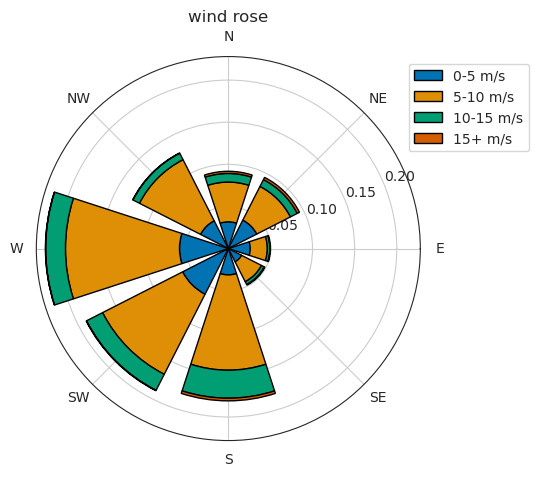

In [6]:
ax = plot_windrose(np.arange(bsp._wd_bins[0], bsp._wd_bins[1],
                   bsp._wd_bins[2]),
                   np.arange(bsp._ws_bins[0], bsp._ws_bins[1],
                   bsp._ws_bins[2]),
                   bsp._wind_dist)
ax.set_title("wind rose")

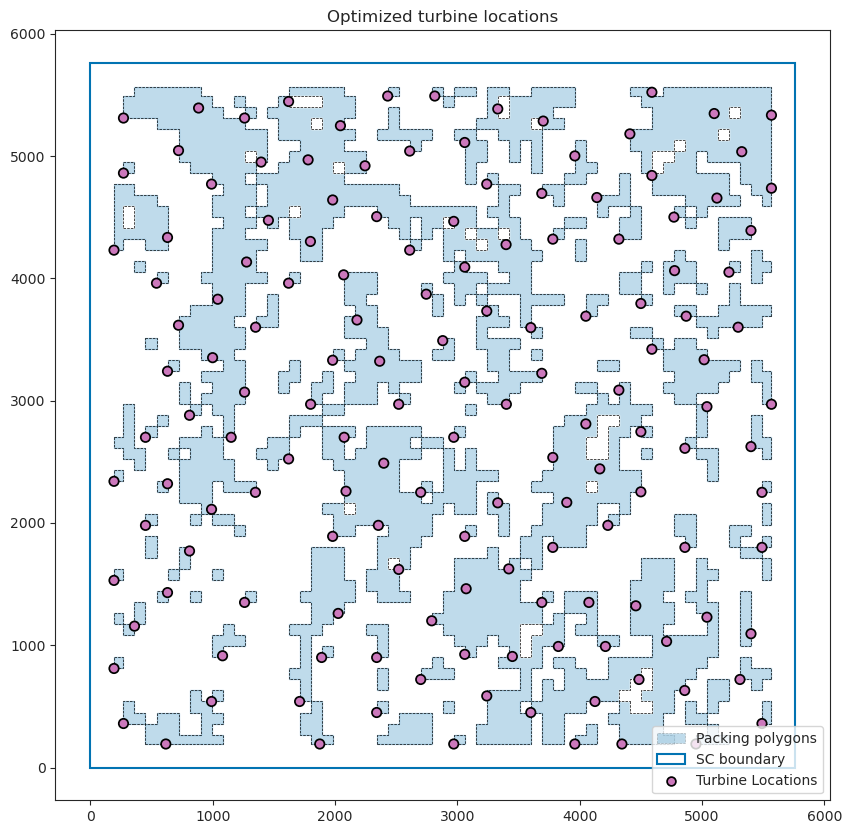

In [7]:
rotor_diameter = bsp.sam_sys_inputs["wind_turbine_rotor_diameter"]
sc_point = bsp._sc_point
pixel_size = sc_point.area_based_pixel_side_length_meters
sc_left = 0
sc_bottom = 0
sc_right = 64 * pixel_size
sc_top = 64 * pixel_size
plot_pad = pixel_size * 2
turb_color = "C4"
boundary_color = "C0"

_, ax = plt.subplots(figsize=(10, 10))
ax, packing_polygons_handle = plot_poly(
    results["packing_polygons"], resolution, pixel_size, ax
)
ax = plot_turbines(bsp.plant_optimizer.turbine_x,
                   bsp.plant_optimizer.turbine_y,
                   rotor_diameter / 2, ax=ax,
                   color=turb_color)

ax.axis("equal")
ax.set_title("Optimized turbine locations")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [packing_polygons_handle, *handles],
    ["Packing polygons", *labels], loc="lower right"
)

plt.show()

# Run Bespoke with Noise

In [8]:
capital_cost_function = """200 * system_capacity * np.exp(-system_capacity /
    1E5 * 0.1 + (1 - 0.1))"""
fixed_operating_cost_function = "0"
variable_operating_cost_function = "0"
balance_of_system_cost_function = "0"
objective_function = "capital_cost / aep"

output_request = ('system_capacity', 'cf_mean', 'cf_profile')
gid = 33
resolution = 64
with tempfile.TemporaryDirectory() as td:
    excl_fp = os.path.join(td, 'ri_exclusions.h5')
    res_fp = os.path.join(td, 'ri_100_wtk_{}.h5')
    shutil.copy(EXCL, excl_fp)
    shutil.copy(RES.format(2012), res_fp.format(2012))
    shutil.copy(RES.format(2013), res_fp.format(2013))
    res_fp = res_fp.format('*')

    TechMapping.run(
        excl_fp, RES.format(2012), dset=TM_DSET, max_workers=1
    )
    bsp_noise = BespokeSinglePlant(gid, excl_fp, res_fp, TM_DSET,
                                   SAM_SYS_INPUTS,
                                   objective_function,
                                   capital_cost_function,
                                   fixed_operating_cost_function,
                                   variable_operating_cost_function,
                                   balance_of_system_cost_function,
                                   ga_kwargs={'max_time': 60 * 5},
                                   excl_dict=EXCL_DICT,
                                   resolution=resolution,
                                   output_request=output_request,
                                   spl_h5_path=SPL,
                                   obs_tiff_fp=OBS,
                                   plant_noise_limit=55)
    results_noise = bsp_noise.run_plant_optimization()

results_noise

{'full_polygons': <MULTIPOLYGON (((5760 4500, 5760 4410, 5760 4320, 5760 4230, 5760 4140, 5760...>,
 'packing_polygons': <MULTIPOLYGON (((192.5 900, 270 900, 270 810, 192.5 810, 192.5 900)), ((192....>,
 'system_capacity': np.float64(82500.0)}

In [9]:
print("nturbs: ", bsp_noise.meta["n_turbines"].values[0])
print("system_capacity (MW): ", bsp_noise.meta["capacity_ac_mw"].values[0])

print("bespoke_aep: ", bsp_noise.meta["optimized_plant_aep"].values[0])
print("bespoke_objective: ",
      bsp_noise.meta["optimized_plant_objective"].values[0])
print("bespoke_annual_cost: ",
      bsp_noise.meta["optimized_plant_capital_cost"].values[0])

nturbs:  55
system_capacity (MW):  82.5
bespoke_aep:  228406832.57848722
bespoke_objective:  0.16361028150632684
bespoke_annual_cost:  37369706.17613476


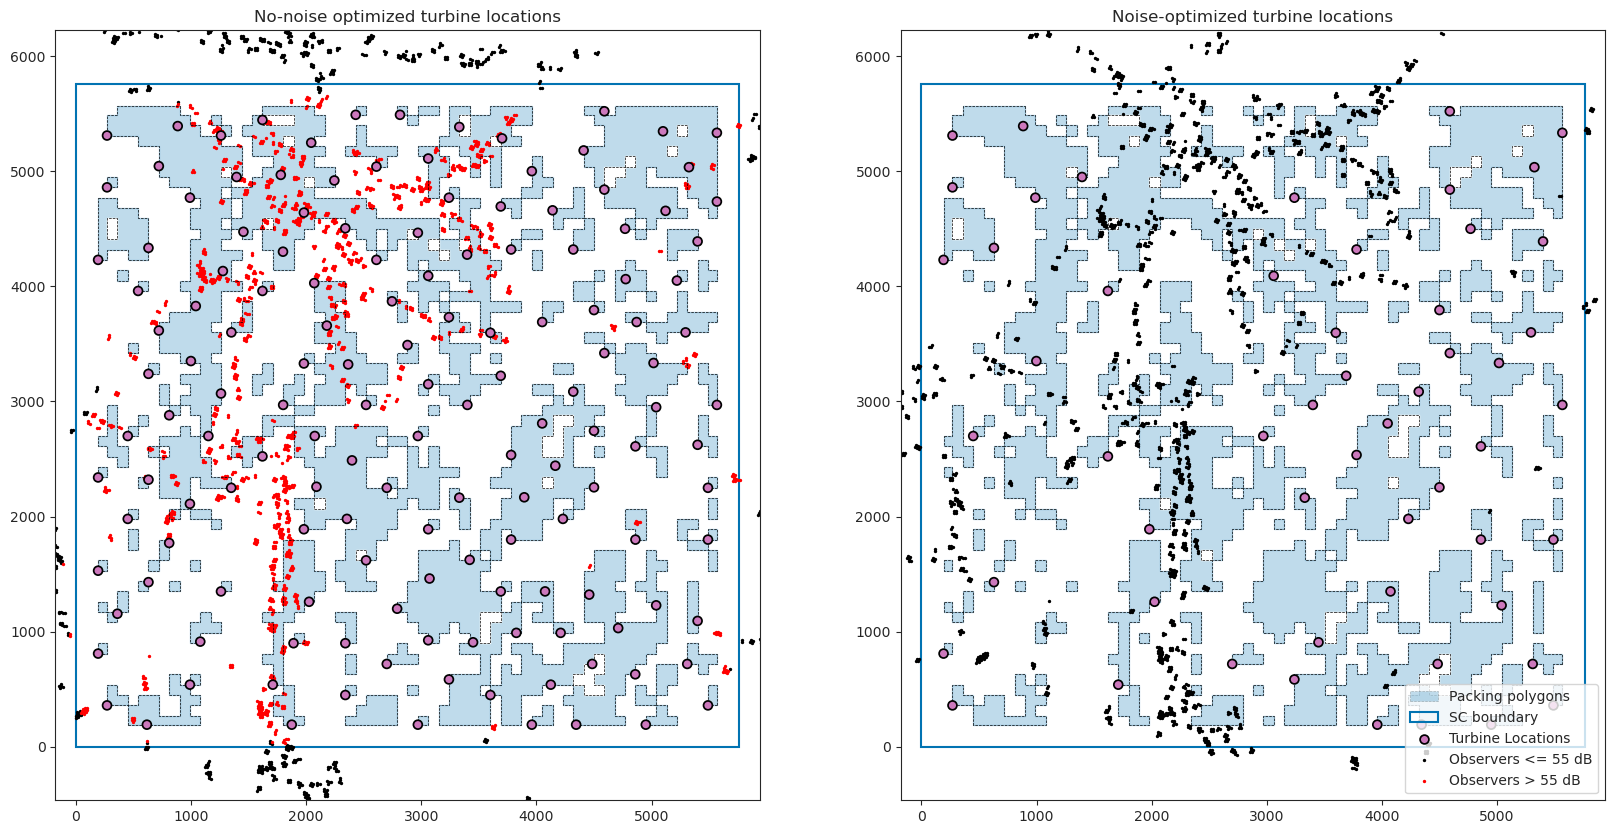

In [10]:
rotor_diameter = bsp.sam_sys_inputs["wind_turbine_rotor_diameter"]
sc_point = bsp._sc_point
pixel_size = sc_point.area_based_pixel_side_length_meters
sc_left = 0
sc_bottom = 0
sc_right = 64 * pixel_size
sc_top = 64 * pixel_size
plot_pad = pixel_size * 2
turb_color = "C4"
boundary_color = "C0"

previous_layout_noise = bsp_noise.plant_optimizer._plant_noise_inputs.build_for_sc_point(
    bsp._sc_point,
    bsp.plant_optimizer.x_locations,
    bsp.plant_optimizer.y_locations,
 )

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
ax = axes[0]
ax, packing_polygons_handle = plot_poly(
    results["packing_polygons"], resolution, pixel_size, ax
)
ax = plot_turbines(
    bsp.plant_optimizer.turbine_x,
    bsp.plant_optimizer.turbine_y,
    rotor_diameter / 2,
    ax=ax,
    color=turb_color,
 )

if previous_layout_noise is not None:
    candidate_turbine_locs = np.c_[
        bsp.plant_optimizer.x_locations,
        bsp.plant_optimizer.y_locations,
    ]
    obs_locs = (
        candidate_turbine_locs[0]
        - previous_layout_noise.shifted_obs_locs[0]
    )
    noise_levels = previous_layout_noise.compute_noise(
        np.array(bsp.plant_optimizer.optimized_design_variables),
        plant_level=True,
    )
    noise_limit = previous_layout_noise.noise_inputs.plant_noise_limit
    violations = noise_levels > noise_limit

    ax.scatter(
        obs_locs[~violations, 0],
        obs_locs[~violations, 1],
        c="black",
        s=2,
        label=f"Observers <= {noise_limit} dB",
    )
    ax.scatter(
        obs_locs[violations, 0],
        obs_locs[violations, 1],
        c="red",
        s=2,
        label=f"Observers > {noise_limit} dB",
    )

handles, labels = ax.get_legend_handles_labels()


ax.axis("equal")
ax.set_xlim(sc_left - plot_pad, sc_right + plot_pad)
ax.set_ylim(sc_bottom - plot_pad, sc_top + plot_pad)
ax.set_title("No-noise optimized turbine locations")


ax = axes[1]
ax, __ = plot_poly(
    results["packing_polygons"], resolution, pixel_size, ax
)
ax = plot_turbines(bsp_noise.plant_optimizer.turbine_x,
                   bsp_noise.plant_optimizer.turbine_y,
                   rotor_diameter / 2, ax=ax,
                   color=turb_color)
if bsp_noise.plant_optimizer.plant_noise is not None:
    turbine_locs = np.c_[bsp_noise.plant_optimizer.turbine_x,
                         bsp_noise.plant_optimizer.turbine_y]
    obs_locs = (
        turbine_locs[0]
        - bsp_noise.plant_optimizer.plant_noise.shifted_obs_locs[0]
    )
    ax = plot_observer_locations(obs_locs[:, 0], obs_locs[:, 1], ax=ax,
                                 size=2)

ax.axis("equal")
ax.set_xlim(sc_left - plot_pad, sc_right + plot_pad)
ax.set_ylim(sc_bottom - plot_pad, sc_top + plot_pad)
ax.set_title("Noise-optimized turbine locations")
ax.legend(
    [packing_polygons_handle, *handles],
    ["Packing polygons", *labels], loc="lower right"
)

plt.show()

In [11]:
stats = bsp_noise.plant_optimizer.plant_noise.violation_stats(
    np.array(bsp.plant_optimizer.optimized_design_variables)
)
num_violations, total_num_obs, pct_violations = stats
print("No-noise optimization:")
print(
    f"    - Number of violations: {num_violations:,}\n    - Total observations: {total_num_obs:,}\n    - Percentage of violations: {pct_violations:.2f}%"
)

No-noise optimization:
    - Number of violations: 1,524
    - Total observations: 2,586
    - Percentage of violations: 58.93%


In [12]:
stats = bsp_noise.plant_optimizer.plant_noise.violation_stats(
    np.array(bsp_noise.plant_optimizer.optimized_design_variables)
)
num_violations, total_num_obs, pct_violations = stats
print("With-noise optimization:")
print(
    f"    - Number of violations: {num_violations:,}\n    - Total observations: {total_num_obs:,}\n    - Percentage of violations: {pct_violations:.2f}%"
)

With-noise optimization:
    - Number of violations: 0
    - Total observations: 2,586
    - Percentage of violations: 0.00%
